# Evaluation Notebook

This file performs evaluation of the diffusion-based predictor, stores results in a Zarr file, and generates plots.

## Configuration

In [4]:
# Set the default model directory.
model_dir = "/data/group/mas/qmas/results/isru_v0/mappo/isru-heuristicComms-e200-20x20-ensemble3-unet2d/wandb/run-20251121_142454-2j1imw7j/files"

# Set the output file.
# output_file = "output.zarr"

# Set the output file automatically.
output_file = model_dir.split("/")[-2] + ".zarr"

## Setup

In [5]:
%reload_ext autoreload
%autoreload 2
from onpolicy.scripts.eval.eval_pettingzoo import main

import os
import yaml
import numpy as np
from copy import deepcopy
from multiprocessing import Process
os.environ["WANDB__SERVICE_WAIT"] = "300"

In [6]:
def convert_args(argsdict):
    # Convert arguments to the appropriate format.
    arglist = []
    for key, value in argsdict.items():
        if type(value) == dict and "value" in value and not key.startswith("_"):
            v = value["value"]
            if v == None:
                continue
            if type(v) == bool:
                if v:
                    arglist.append(f"--{key}")
                else:
                    arglist.append(f"--no-{key}")
            else:
                arglist.append(f"--{key}")
                arglist.append(str(v))
    return arglist


def wrap_arg_val(val):
    return {"value": val}


def load_args(model_dir):
    # Load arguments from the config file.
    config_file = os.path.join(model_dir, "config.yaml")
    args = yaml.load(open(config_file), Loader=yaml.FullLoader)

    # Set required eval-specific arguments. Do not change these!
    args["use_wandb"] = wrap_arg_val(False)
    args["use_render"] = wrap_arg_val(False)
    args["use_eval"] = wrap_arg_val(True)
    args["model_dir"] = wrap_arg_val(model_dir)
    args["eval_output_file"] = wrap_arg_val(output_file)


    # Set default arguments for evaluation. Feel free to change these!
    args["cuda"] = wrap_arg_val(True)
    args["cuda_idx"] = wrap_arg_val(0)
    args["cuda_idx_predictor"] = wrap_arg_val(1)
    args["eval_episodes"] = wrap_arg_val(1)
    args["episode_length"] = wrap_arg_val(200)
    args["seed"] = wrap_arg_val(1)


    return args

# Load arguments for the default model.
args = load_args(model_dir)

FileNotFoundError: [Errno 2] No such file or directory: '/data/group/mas/qmas/results/isru_v0/mappo/isru-heuristicComms-e200-20x20-ensemble3-unet2d/wandb/run-20251121_142454-2j1imw7j/files/config.yaml'

# Evaluation

In [ ]:
# Check if the output file already exists. If so, skip this cell.
if os.path.exists(args["eval_output_file"]["value"]):
    # print("Output file already exists. Skipping evaluation.")
    print("Output file already exists. Overwriting evaluation.")

# else:
if True:
    processes = []

    def start_process(args):
        p = Process(target=main, args=[convert_args(args)])
        processes.append(p)
    
    # Add the full visibility baseline.
    argscopy = deepcopy(args)
    argscopy["experiment_name"] = wrap_arg_val(f"fully_observable")
    argscopy["prediction_disable"] = wrap_arg_val(True)
    argscopy["observation_radius"] = wrap_arg_val(999999)
    argscopy["noisy_memory"] = wrap_arg_val(False)
    start_process(argscopy)
    
    # Add the predictor test.
    argscopy = deepcopy(args)
    argscopy["experiment_name"] = wrap_arg_val(f"predictor")
    argscopy["prediction_disable"] = wrap_arg_val(False)
    argscopy["diffusion_autoregression_steps"] = wrap_arg_val(8)
    argscopy["noisy_memory"] = wrap_arg_val(True)
    start_process(argscopy)

    # Add the noisy memory test.
    argscopy = deepcopy(args)
    argscopy["experiment_name"] = wrap_arg_val(f"noisy_memory")
    argscopy["prediction_disable"] = wrap_arg_val(True)
    argscopy["noisy_memory"] = wrap_arg_val(True)
    start_process(argscopy)

    # JOIN ALL PROCESSES
    # Up to MAX_PROCESSES processes can run simultaneously.
    MAX_PROCESSES = 3
    running_processes = []
    while len(processes) > 0 or len(running_processes) > 0:
        # Start new processes if we have capacity.
        while len(running_processes) < MAX_PROCESSES and len(processes) > 0:
            p = processes.pop(0)
            p.start()
            running_processes.append(p)
        
        # Check for finished processes.
        for p in running_processes:
            if not p.is_alive():
                p.join()
        running_processes = [p for p in running_processes if p.is_alive()]
    print("All processes finished!")

Pettingzoo environment isru_zoo.isru_v0.parallel_env_map_obs has additional arguments.


/home/luv9292/qmas_task_allocation/onpolicy/scripts/train/train_pettingzoo.py:158: UserWarning: Unknown arguments: ['--no-available_actions_mask', '--no-curriculum_num_resources', '--episode_max', '1666', '--no-noisy_memory', '--no-randomize_num_resources', '--no-share_reward', '--no-torch_compile']
  warnings.warn(f"Unknown arguments: {unknown_args}")


u are choosing to use mappo, we set use_recurrent_policy & use_naive_recurrent_policy to be False
Pettingzoo environment isru_zoo.isru_v0.parallel_env_map_obs has additional arguments.


/home/luv9292/qmas_task_allocation/onpolicy/scripts/train/train_pettingzoo.py:158: UserWarning: Unknown arguments: ['--no-available_actions_mask', '--no-curriculum_num_resources', '--episode_max', '1666', '--no-noisy_memory', '--no-randomize_num_resources', '--no-share_reward', '--no-torch_compile']
  warnings.warn(f"Unknown arguments: {unknown_args}")


u are choosing to use mappo, we set use_recurrent_policy & use_naive_recurrent_policy to be False
Pettingzoo environment isru_zoo.isru_v0.parallel_env_map_obs has additional arguments.


/home/luv9292/qmas_task_allocation/onpolicy/scripts/train/train_pettingzoo.py:158: UserWarning: Unknown arguments: ['--no-available_actions_mask', '--no-curriculum_num_resources', '--episode_max', '1666', '--no-randomize_num_resources', '--no-share_reward', '--no-torch_compile']
  warnings.warn(f"Unknown arguments: {unknown_args}")


u are choosing to use mappo, we set use_recurrent_policy & use_naive_recurrent_policy to be False
Pettingzoo arguments validated: base
Pettingzoo environment isru_zoo.isru_v0.parallel_env_map_obs has additional arguments validation function.
Pettingzoo arguments validated: isru_zoo.isru_v0.parallel_env_map_obs
choose to use gpu...
PettingzooEnv: Attempting to pass unpacked argparse namespace to environment.
PettingzooEnv: Passing the following arguments to the environment: {'max_cycles': 200, 'num_extractors': 2, 'num_haulers': 2, 'num_prospectors': 2, 'num_superbots': 0, 'num_obstacles': 0, 'num_resources': 20, 'randomize_num_resources': False, 'curriculum_num_resources': False, 'world_size': 20, 'world_no_reset': True, 'observation_radius': 999999, 'available_actions_mask': False, 'hauler_capacity': 5.0, 'hauler_pickup_threshold': 1.5, 'noisy_memory': False, 'communication_mode': 'nearest', 'render_mode': 'human', 'episode_max': 1666}
Pettingzoo arguments validated: base
Pettingzoo e

/home/luv9292/miniconda3/envs/qmas/lib/python3.10/site-packages/torchrl/__init__.py:43: UserWarning: failed to set start method to spawn, and current start method for mp is fork.
  warn(
/home/luv9292/miniconda3/envs/qmas/lib/python3.10/site-packages/torchrl/__init__.py:43: UserWarning: failed to set start method to spawn, and current start method for mp is fork.
  warn(
/home/luv9292/miniconda3/envs/qmas/lib/python3.10/site-packages/torchrl/__init__.py:43: UserWarning: failed to set start method to spawn, and current start method for mp is fork.
  warn(


R_Actor: Use GNN: False, Use CNN: True, Use MLP: True
Action output distributions:
  0: DiagGaussian, action_dim: 2, available_action_dim: inf
  1: Categorical, action_dim: 1, available_action_dim: 2
R_Actor: Use GNN: False, Use CNN: True, Use MLP: True
Action output distributions:
  0: DiagGaussian, action_dim: 2, available_action_dim: inf
  1: Categorical, action_dim: 1, available_action_dim: 2
R_Actor: Use GNN: False, Use CNN: True, Use MLP: True
Action output distributions:
  0: DiagGaussian, action_dim: 2, available_action_dim: inf
  1: Categorical, action_dim: 1, available_action_dim: 2
R_Critic: Use CNN: True, Use MLP: True
R_Critic: Use CNN: True, Use MLP: True
R_Critic: Use CNN: True, Use MLP: True
Creating ensemble of 3 predictors.
QmasPolicy: Using diffusion model type jannerunet with prediction horizon 16 and transition dimension 5200.
Creating ensemble of 3 predictors.
QmasPolicy: Using diffusion model type jannerunet with prediction horizon 16 and transition dimension 520

# Analysis

In [ ]:
import zarr
output = zarr.open(output_file, mode='r')
output.tree()

Tree(nodes=(Node(disabled=True, name='/', nodes=(Node(disabled=True, name='fully_observable', nodes=(Node(disa…

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


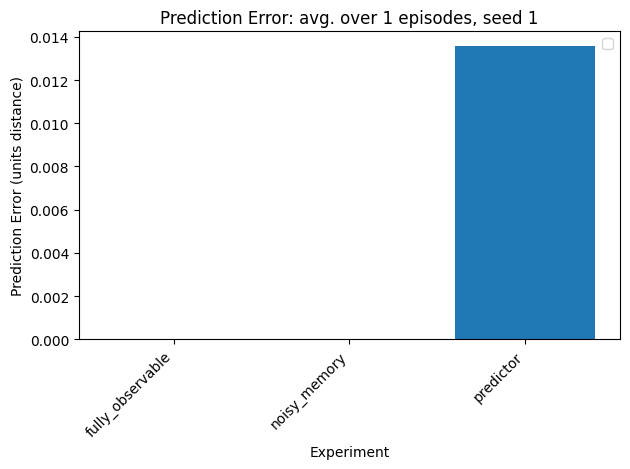

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


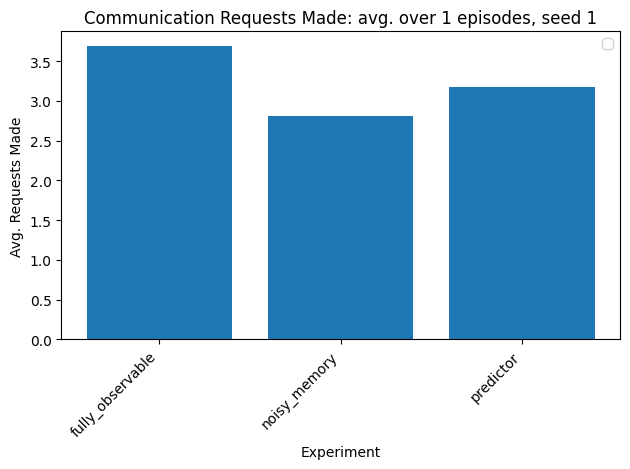

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


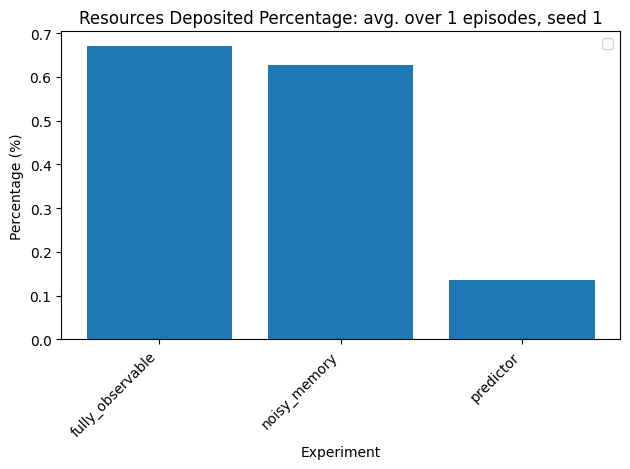

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
categories = {
    'prediction_error_mean': {
        'title': 'Prediction Error',
        'ylabel': 'Prediction Error (units distance)',
        'xlabel': 'Experiment',
        'type': 'bar',
        # Average over all episodes and all timesteps.
        'data': [np.mean(output[experiment]['prediction_error_mean']) for experiment in output],
    },
    'communication/requests_made': {
        'title': 'Communication Requests Made',
        'ylabel': 'Avg. Requests Made',
        'xlabel': 'Experiment',
        'type': 'bar',
        # Average over all episodes and all timesteps.
        'data': [np.mean(output[experiment]['communication/requests_made']) for experiment in output]
    },
    'resources/deposited_percentage': {
        'title': 'Resources Deposited Percentage',
        'ylabel': 'Percentage (%)',
        'xlabel': 'Experiment',
        'type': 'bar',
        # Average over all episodes and all timesteps.
        'data': [np.mean(output[experiment]['resources/deposited_percentage']) for experiment in output]
    },
}

for category in categories:
    if categories[category]['type'] == 'line':
        if type(categories[category]['data']) == dict:
            for series, values in categories[category]['data'].items():
                x = np.linspace(0, 1, len(values))
                plt.plot(x, values, label=series)
        else:
            values = categories[category]['data']
            x = np.linspace(0, 1, len(values))
            plt.plot(x, values)
    elif categories[category]['type'] == 'bar':
        values = categories[category]['data']
        x = np.arange(len(values))
        plt.bar(x, values)
        plt.xticks(x, [experiment for experiment in output], rotation=45, ha='right')
    
    # Add a vertical line at x=0.0 for lambda_crit
    # plt.axvline(x=0.0, color='r', linestyle='--', label='λ_crit')
    
    title = categories[category]['title']
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Scenario' if "xlabel" not in categories[category] else categories[category]['xlabel'])
    plt.ylabel(f"Timesteps out of {args['episode_length']['value']}" if "ylabel" not in categories[category] else categories[category]['ylabel'])
    plt.title(f"{title}: avg. over {args['eval_episodes']['value']} episodes, seed {args['seed']['value']}")
    plt.legend()
    plt.tight_layout()
    plt.show()